This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# Pseudo-symmetry

A crystal is pseudo-symmetric when two orientations that are *not* related by a true symmetry operation still produce nearly identical diffraction patterns.
Indexing then has two (or more) almost equally good answers, and noise decides which one wins: the orientation map fractures into speckle or entire grains flip into a wrong variant.
Well known cases include tetragonal crystals with a near-cubic axial ratio and hexagonal or trigonal phases with strong sub-cell alignments.

[Lenthe, Singh & De Graef (2019)](https://doi.org/10.1107/S1600576719011233) showed that these problem operators can be *predicted* from the master pattern alone: the rotational autocorrelation of the master has a peak at every rotation that maps the pattern nearly onto itself, and every strong peak that is not a true symmetry operation is a pseudo-symmetry candidate.
Their `MasterXcorr` program ships with [EMSphInx](https://github.com/EMsoft-org/EMSphInx) ([Lenthe et al., 2019](https://doi.org/10.1016/j.ultramic.2019.112841)), whose indexing loop can then re-score every candidate variant of each best orientation.
kikuchipy ports both halves: [find_pseudo_symmetry_operators()](../reference/generated/kikuchipy.indexing.find_pseudo_symmetry_operators.rst) predicts operators from a [MasterPatternHarmonics](../reference/generated/kikuchipy.indexing.MasterPatternHarmonics.rst), and [EBSD.spherical_indexing()](../reference/generated/kikuchipy.signals.EBSD.spherical_indexing.rst) accepts them through its `pseudo_symmetry_ops` parameter.
(One honest note on the heritage: in the shipped EMSphInx command line release the pseudo-symmetry re-scoring loop is silently inert, operators are loaded but never applied; kikuchipy ports the intended loop.)

This tutorial builds on the [spherical indexing](spherical_indexing.ipynb) tutorial, which covers the harmonic transform, detector calibration and bandwidth selection in detail.
The same operators also work with the NCC refinement engine through [EBSD.refine_orientation()](../reference/generated/kikuchipy.signals.EBSD.refine_orientation.rst), which uses the same `pseudo_symmetry_ops` convention.


In [1]:
# Exchange inline for notebook or qt5 (from pyqt) for interactive plotting
%matplotlib inline

import os
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from orix.crystal_map import Phase
from orix.quaternion import Orientation, Rotation

import kikuchipy as kp
from kikuchipy.indexing import (
    MasterPatternHarmonics,
    find_pseudo_symmetry_operators,
    read_emsphinx_psym_file,
    write_emsphinx_psym_file,
)

## Operator discovery on the nickel master

`find_pseudo_symmetry_operators()` correlates a master pattern with itself over all rotations, extracts the local maxima of the correlation volume, refines each one, and reports every peak whose intensity (relative to a reference maximum) clears a cutoff.
With `exclude_symmetry=False` the raw list is returned, true symmetry operations included, which is a useful sanity check: on the nickel master the finder should simply rediscover the proper rotations of the point group $m\bar{3}m$.


In [2]:
mp_ni = kp.data.nickel_ebsd_master_pattern_small(
    projection="lambert", hemisphere="both"
)
h_ni = mp_ni.get_spherical_harmonics(bandwidth=68)
ops_ni_all = find_pseudo_symmetry_operators(
    h_ni, bandwidth=68, cutoff=0.5, exclude_symmetry=False
)
print(ops_ni_all.operators.size, "operators")
print("intensities:", np.round(ops_ni_all.intensities, 4))
print(
    "rotation angles (deg):",
    np.round(np.rad2deg(ops_ni_all.operators.angle), 2),
)

23 operators
intensities: [1.4739 1.4739 1.4739 1.4739 1.4739 1.4739 1.4739 1.3042 1.3042 1.3042
 1.3042 1.3042 1.3042 1.3042 1.3042 1.3042 1.3042 1.3042 1.3041 1.3041
 1.3041 1.3041 0.8529]
rotation angles (deg): [180. 180. 180. 180. 180.  90.  90. 180.  90.  90. 120. 120. 120. 120.
 180. 180.  90.  90. 120. 120. 120. 120. 180.]


The rotation angles are the 180, 90 and 120 degree families of the 24 proper octahedral rotations (the identity peak is not extracted because its grid cell sits at an edge of the stored volume; the other 23 proper rotations are each recovered exactly once, the weakest row being a two-fold recovered about 2 degrees away from the exact rotation).

Two conventions to be aware of when reading the intensities:

- Intensities are **relative**, normalized by a reference maximum refined from a near-identity seed.
  On this master that reference refinement stalls below the true peak height, so the true symmetry operations report intensities *above* one.
  This is faithful to `MasterXcorr`; read the numbers as relative strengths, not as fractions of a perfect self-match.
- The `cutoff` is applied both when candidate grid cells are collected and again after refinement, so it is a knob you should expect to tune per master (more on this below, with a real material).

With the default `exclude_symmetry=True`, every peak within a small angular threshold of a proper rotation of the master's own point group is removed, and only genuine pseudo-symmetry candidates remain:


In [3]:
ops_ni = find_pseudo_symmetry_operators(h_ni, bandwidth=68, cutoff=0.5)
ops_ni.operators.size

0

Zero operators: nickel has no genuine pseudo-symmetry.
An empty result here is a perfectly good result, and it is what you should expect for most high symmetry cubic metals.


## Manufactured pseudo-symmetry

To watch the machinery act on shipped data we manufacture a pseudo-symmetric master, by blending the nickel master with a rotated copy of itself using [MasterPatternHarmonics.rotate()](../reference/generated/kikuchipy.indexing.MasterPatternHarmonics.rotate.rst).
The blend $g = f + \lambda\, f_S$, where $f_S$ is $f$ rotated by $S$ (here 120 degrees about $z$) and $\lambda = 0.7$, carries a false three-fold axis: rotating $g$ by $S$ maps the copy onto the original, overlapping a fraction $\lambda/(1 + \lambda^2) \approx 0.47$ of the autocorrelation weight.
The blend itself has no true symmetry, so we give it point group 1.


In [4]:
s_z120 = Rotation.from_axes_angles([0, 0, 1], np.deg2rad(120))
h60 = mp_ni.get_spherical_harmonics(bandwidth=60)
blend = MasterPatternHarmonics(
    h60.alm + 0.7 * h60.rotate(s_z120).alm,
    phase=Phase("blend", point_group="1"),
)
found = find_pseudo_symmetry_operators(blend, bandwidth=60, cutoff=0.25)
angles_to_s = np.rad2deg((found.operators.outer(~s_z120)).angle).ravel()
i_best = int(angles_to_s.argmin())
print(found.operators.size, "operators above cutoff 0.25")
print(
    f"the built-in 120 degree operator is row {i_best}: "
    f"{angles_to_s[i_best]:.3f} deg off, "
    f"intensity {found.intensities[i_best]:.4f}"
)

99 operators above cutoff 0.25
the built-in 120 degree operator is row 34: 0.175 deg off, intensity 0.5039


The manufactured operator is recovered, at an intensity close to the predicted $\lambda/(1+\lambda^2)$.
It sits in a long list: blending two copies of a cubic master also creates peaks at every composition of the blend rotation with the octahedral rotations of either copy, and point group 1 excludes none of them.
On a real master the phase's point group prunes this list for you; the cutoff does the rest.

### Rescuing indexing with operators

Discovery tells you which operators *might* bite.
To see one actually bite, we push the blend towards degeneracy: two copies rotated by $\pm 120$ degrees about a general axis, at $\lambda = 0.95$.
The true orientation's correlation peak (weight $1 + 2\lambda^2$) then beats each false one (weight $2\lambda + \lambda^2$) by only $(1-\lambda)^2$, a quarter of a percent, so on a coarse Euler grid with noisy patterns the search can land in the wrong basin, and refinement will happily polish the wrong basin instead of jumping out of it.

We synthesize one pattern from this blend at a known orientation, repeat it over a small 3 x 3 map with strong independent noise, and index it.


In [5]:
s_ps = Rotation.from_axes_angles([1, 2, 3], np.deg2rad(120))
h53 = mp_ni.get_spherical_harmonics(bandwidth=53)
blend_strong = MasterPatternHarmonics(
    h53.alm + 0.95 * (h53.rotate(s_ps).alm + h53.rotate(~s_ps).alm),
    phase=Phase("blend", point_group="1"),
)

det = kp.data.nickel_ebsd_small().detector.deepcopy()
det.pc = det.pc_average

rot_true = Rotation.from_axes_angles([1, 2, 1], np.deg2rad(40))
pattern = (
    blend_strong.to_master_pattern()
    .get_patterns(
        rot_true,
        det,
        compute=True,
        dtype_out=np.uint8,
        show_progressbar=False,
    )
    .data.reshape((60, 60))
)
rng = np.random.default_rng(8)
patterns = np.clip(
    np.tile(pattern, (9, 1, 1)) + rng.normal(0, 40, (9, 60, 60)), 0, 255
).astype(np.uint8)
s_blend = kp.signals.EBSD(patterns.reshape((3, 3, 60, 60)))
s_blend

<EBSD, title: , dimensions: (3, 3|60, 60)>

In [6]:
xmap_no = s_blend.spherical_indexing(blend_strong, det, bandwidth=53)
mis_no = np.rad2deg((xmap_no.rotations * ~rot_true).angle)
print("misorientation to the true orientation (deg):")
print(np.round(mis_no.reshape((3, 3)), 2))

Spherical indexing information:
  Phase(s): blend (1; 1-fold, no mirror)
  Bandwidth: 53 (Euler side length 105, half cell 1.71 deg)
  Correlation: normalized
  Refinement: Newton (on)
  Preprocessing: n_regions = 10, gaussian_background = False
  Projection center (Bruker): (0.4251, 0.2134, 0.5007)
  Indexing 9 pattern(s) in 9 chunk(s) of up to 1 pattern(s)
  Estimated memory per worker: 26 MB
[                                        ] | 0% Completed | 583.40 us

[##                                      ] | 5% Completed | 108.78 ms

[########################################] | 100% Completed | 210.04 ms

  Indexing speed: 40.40980 patterns/s

misorientation to the true orientation (deg):
[[119.8  120.01 119.89]
 [119.89 119.75 119.89]
 [119.91 119.72 119.86]]


Every point lands about 120 degrees from the truth: the coarse search picked a pseudo basin, and Newton refinement, which only ever improves the orientation it is given, polished the wrong answer.

Now pass the two blend operators as `pseudo_symmetry_ops`.
For each indexed point, every operator variant of the best orientation is re-seeded, refined and re-scored, and the best variant wins; the winning variant index is reported in the crystal map property `pseudo_symmetry_index` (0 for the original orientation, $i$ for `ops[i - 1]`).


In [7]:
ops_ps = Rotation(np.vstack((s_ps.data, (~s_ps).data)))
xmap_ps = s_blend.spherical_indexing(
    blend_strong, det, bandwidth=53, pseudo_symmetry_ops=ops_ps
)
mis_ps = np.rad2deg((xmap_ps.rotations * ~rot_true).angle)
print("misorientation to the true orientation (deg):")
print(np.round(mis_ps.reshape((3, 3)), 2))
print("score gain over the run without operators:")
print(np.round(xmap_ps.scores - xmap_no.scores, 3).reshape((3, 3)))

Spherical indexing information:
  Phase(s): blend (1; 1-fold, no mirror)
  Bandwidth: 53 (Euler side length 105, half cell 1.71 deg)
  Correlation: normalized
  Refinement: Newton (on)
  Preprocessing: n_regions = 10, gaussian_background = False
  Projection center (Bruker): (0.4251, 0.2134, 0.5007)
  Indexing 9 pattern(s) in 9 chunk(s) of up to 1 pattern(s)
  Estimated memory per worker: 26 MB
[                                        ] | 0% Completed | 510.30 us

[########################################] | 100% Completed | 103.47 ms

  Indexing speed: 77.64354 patterns/s


misorientation to the true orientation (deg):
[[0.31 0.04 0.17]
 [0.23 0.26 0.27]
 [0.14 0.36 0.25]]
score gain over the run without operators:
[[0.002 0.001 0.004]
 [0.004 0.003 0.004]
 [0.003 0.003 0.005]]


In [8]:
xmap_ps

Phase  Orientations   Name  Space group  Point group  Proper point group     Color
    0    9 (100.0%)  blend         None            1                   1  tab:blue
Properties: scores, iq, pseudo_symmetry_index
Scan unit: px

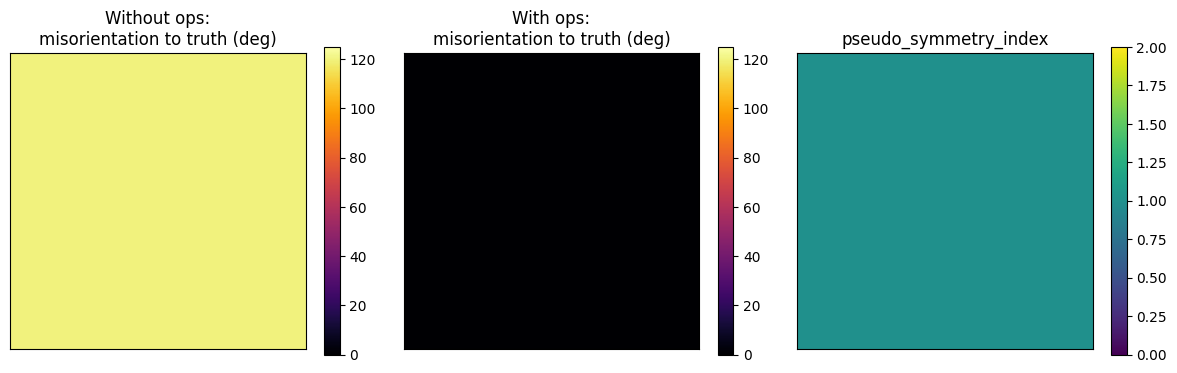

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 3.6))
for ax, image, title, kwargs in zip(
    axes,
    [
        mis_no.reshape((3, 3)),
        mis_ps.reshape((3, 3)),
        xmap_ps.pseudo_symmetry_index.reshape((3, 3)),
    ],
    [
        "Without ops:\nmisorientation to truth (deg)",
        "With ops:\nmisorientation to truth (deg)",
        "pseudo_symmetry_index",
    ],
    [
        dict(vmin=0, vmax=125, cmap="inferno"),
        dict(vmin=0, vmax=125, cmap="inferno"),
        dict(vmin=0, vmax=2, cmap="viridis"),
    ],
):
    im = ax.imshow(image, **kwargs)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax)
fig.tight_layout()

All nine points are rescued to a fraction of a degree, the winning scores rise, and `pseudo_symmetry_index` records *which* operator variant won at every point (here variant 1 everywhere, the $+120$ degree copy).
The property exists only when `pseudo_symmetry_ops` was passed; with `n_best > 1` a per-rank `nbest_pseudo_symmetry_index` is stored as well.
Note that operators close to a true symmetry operation of the phase would produce near-ties whose winner flips on noise, which is exactly why `find_pseudo_symmetry_operators()` excludes true operations by default.


## A real material: titanium

<div class="alert alert-info">

This section uses a local EMsoft master pattern of hexagonal alpha titanium (20 kV), which cannot be shipped with kikuchipy.
It runs if the file `Ti-alpha-master-20kV.h5` is found in the directory named by the environment variable `KIKUCHIPY_LOCAL_MASTERS_DIR`; without it, the cells below do nothing and the rest of the tutorial is unaffected.
The stored outputs show a run with the file present.

</div>


In [10]:
ti_path = None
ti_dir = os.environ.get("KIKUCHIPY_LOCAL_MASTERS_DIR")
if ti_dir and (Path(ti_dir) / "Ti-alpha-master-20kV.h5").is_file():
    ti_path = Path(ti_dir) / "Ti-alpha-master-20kV.h5"
print(
    "Ti master:",
    ti_path.name if ti_path else "not available, cells below do nothing",
)

Ti master: Ti-alpha-master-20kV.h5


In [11]:
if ti_path:
    mp_ti = kp.load(ti_path, projection="lambert", hemisphere="both")
    print(
        "space group:",
        mp_ti.phase.space_group.short_name,
        "- point group:",
        mp_ti.phase.point_group.name,
    )
    # Catch the expected warnings to print them without file paths
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        h_ti = mp_ti.get_spherical_harmonics(bandwidth=68)
    for w in caught:
        print(f"{w.category.__name__}: {w.message}")
    print(
        "n_fold:",
        h_ti.n_fold,
        "- equatorial mirror:",
        h_ti.has_equatorial_mirror,
    )

space group: P63/mmc - point group: 6/mmm
n_fold: 1 - equatorial mirror: False


The warning above is expected for every hexagonal master and worth understanding.
The phase metadata is correct (space group 194, point group $6/mmm$), but the master pattern is stored on a square Lambert grid, which shares a four-fold axis with cubic masters yet cannot carry a six-fold axis exactly.
The interpolated pattern therefore leaks a tiny fraction (about $4 \times 10^{-4}$) of its power into harmonic orders a six-fold axis forbids, and kikuchipy conservatively downgrades the symmetry flags it uses to skip redundant work in the correlator.
Only speed is affected; the symmetry *filter* below reads the phase's point group directly and is not fooled.

Every fresh harmonics build re-validates the flags and repeats the warning; inside `find_pseudo_symmetry_operators` the checks run on internal working copies with the constant background removed, where the leaked *fraction* of the remaining power reads larger (about $2 \times 10^{-2}$).
The next cell therefore silences the repeats before moving on.

First the sanity check, rediscovering the true symmetry:


In [12]:
# Silence the repeats of the now-explained warning (see above)
warnings.filterwarnings(
    "ignore", message="The coefficients carry a relative power"
)
if ti_path:
    r_proper = find_pseudo_symmetry_operators(
        h_ti, bandwidth=68, cutoff=0.5, exclude_symmetry=False
    )
    print(r_proper.operators.size, "operators")
    print("intensities:", np.round(r_proper.intensities, 4))
    print(
        "rotation angles (deg):",
        np.round(np.rad2deg(r_proper.operators.angle), 2),
    )

9 operators
intensities: [1.5348 1.5345 1.5345 1.4943 1.4942 1.4941 1.494  1.494  1.494 ]
rotation angles (deg): [180. 180. 180. 180. 180. 180.  60.  60. 180.]


Nine proper rotations of 622 (180 and 60 degree families), again with intensities above one.
Now the genuine pseudo-symmetry.
At the default cutoff of 0.5 the answer is empty, because alpha titanium's pseudo-symmetry peaks are of *moderate* strength; they surface once the cutoff is lowered:


In [13]:
if ti_path:
    r_05 = find_pseudo_symmetry_operators(h_ti, bandwidth=68, cutoff=0.5)
    print("cutoff 0.50:", r_05.operators.size, "operators")
    r_ti = find_pseudo_symmetry_operators(h_ti, bandwidth=68, cutoff=0.39)
    print(
        f"cutoff 0.39: {r_ti.operators.size} operators, intensities "
        f"{r_ti.intensities.min():.4f}-{r_ti.intensities.max():.4f}"
    )
    families = np.round(np.rad2deg(r_ti.operators.angle), 1)
    for angle, count in zip(*np.unique(families, return_counts=True)):
        print(f"  {count} operators with rotation angle {angle} deg")

cutoff 0.50: 0 operators


cutoff 0.39: 54 operators, intensities 0.4223-0.4633
  6 operators with rotation angle 83.3 deg
  6 operators with rotation angle 90.0 deg
  12 operators with rotation angle 104.5 deg
  6 operators with rotation angle 128.1 deg
  12 operators with rotation angle 138.6 deg
  12 operators with rotation angle 180.0 deg


Choosing the cutoff is the one judgement call of operator discovery, so here is how these numbers behave on this master:

- The 54 operators above fall into a handful of angular families at intensities 0.42-0.46, all far (more than 60 degrees) from any true 622 rotation: genuine pseudo-symmetry candidates of moderate strength.
- The returned set is **not monotone in the cutoff**: candidates are collected by their unrefined grid values but kept by their refined intensities, faithfully to `MasterXcorr`.
  On this master, cutoffs 0.38-0.40 return the identical set, 0.41-0.43 return shrinking subsets of the weaker families, and 0.44 upwards returns nothing.
- A practical recipe: sweep the cutoff downwards until the list stabilizes over a small range, and treat families that appear and disappear within the sweep as borderline.


### Do these operators actually bite?

An intensity of 0.46 means the false orientation reproduces just under half of the master's autocorrelation weight.
Whether that is enough to confuse indexing depends on the detector geometry, the bandwidth and the noise, so we measure instead of guessing: simulate patterns at nine random orientations, add increasing noise, and index them *with* all 54 discovered operators in play, so every variant gets its chance to win at every point.


In [14]:
if ti_path:
    rng = np.random.default_rng(42)
    quats = rng.normal(size=(9, 4))
    rot_ti = Rotation(quats / np.linalg.norm(quats, axis=1, keepdims=True))
    pats = mp_ti.get_patterns(
        rot_ti, det, compute=True, dtype_out=np.uint8, show_progressbar=False
    ).data.reshape((9, 60, 60))
    target = Orientation(rot_ti, symmetry=mp_ti.phase.point_group)
    for sigma in (10, 40, 80):
        noisy = np.clip(
            pats + np.random.default_rng(7).normal(0, sigma, pats.shape),
            0,
            255,
        ).astype(np.uint8)
        xm = kp.signals.EBSD(
            noisy.reshape((3, 3, 60, 60))
        ).spherical_indexing(
            h_ti,
            det,
            bandwidth=68,
            pseudo_symmetry_ops=r_ti.operators,
            verbose=0,
        )
        wins = int(np.count_nonzero(xm.pseudo_symmetry_index))
        err = np.rad2deg(
            Orientation(
                xm.rotations, symmetry=mp_ti.phase.point_group
            ).angle_with(target)
        )
        print(
            f"noise sigma {sigma:3d}: {wins}/9 pseudo-symmetry variants won, "
            f"max disorientation to truth {err.max():.2f} deg"
        )

noise sigma  10: 0/9 pseudo-symmetry variants won, max disorientation to truth 0.41 deg


noise sigma  40: 0/9 pseudo-symmetry variants won, max disorientation to truth 0.48 deg


noise sigma  80: 0/9 pseudo-symmetry variants won, max disorientation to truth 0.61 deg


An honest negative: at this geometry and bandwidth, not one of the 54 moderate-intensity operators ever beats the true orientation, even at noise levels (sigma 80 on an 8-bit pattern) far beyond realistic acquisitions, and the indexed orientations stay within a fraction of a degree of the truth.
That is the intended reading of operator discovery: it flags the *candidates* worth guarding against, cheaply (one extra Newton refinement per operator per pattern), and the guard also measures whether the risk materializes at all.
For this titanium master at these conditions, it does not; for a weaker geometry, a coarser bandwidth or a more degenerate phase, the same machinery reports exactly where and how often the variants win, as the manufactured example above showed.


## Exchanging operators with EMSphInx

Operators travel between kikuchipy and EMSphInx as EMsoft-style quaternion angle files (the `psymfile` of the `IndexEBSD` namelist).
[write_emsphinx_psym_file()](../reference/generated/kikuchipy.indexing.write_emsphinx_psym_file.rst) writes them (as does the `save()` method of a discovery result), and [read_emsphinx_psym_file()](../reference/generated/kikuchipy.indexing.read_emsphinx_psym_file.rst) reads them back, ready to pass as `pseudo_symmetry_ops` to either indexing engine.
The file rows store the quaternion *conjugates* of kikuchipy's operators, so that EMSphInx's own variant composition realizes exactly the same candidate orientations; the round trip through the file is exact.


In [15]:
temp_dir = Path(tempfile.mkdtemp())
psym_file = temp_dir / "blend_ops.txt"
write_emsphinx_psym_file(psym_file, ops_ps)
print(psym_file.read_text())
ops_back = read_emsphinx_psym_file(psym_file)
print(
    "largest round-trip deviation (deg):",
    np.rad2deg(float((ops_back * ~ops_ps).angle.max())),
)

qu
2
0.5000000000000001 -0.23145502494313785 -0.4629100498862757 -0.6943650748294136
0.5000000000000001 0.23145502494313785 0.4629100498862757 0.6943650748294136

largest round-trip deviation (deg): 0.0


## Summary

- `find_pseudo_symmetry_operators()` predicts pseudo-symmetry operators from a master pattern's rotational autocorrelation; with `exclude_symmetry=False` it rediscovers the true point group rotations (a good sanity check), and with the default `exclude_symmetry=True` only genuine candidates remain, which for many phases (like nickel) is an empty list.
- Intensities are relative to a reference maximum and can exceed one; the cutoff interacts with both the candidate collection and the refined intensities, so sweep it until the returned set stabilizes.
- `pseudo_symmetry_ops` on `EBSD.spherical_indexing()` (and on `EBSD.refine_orientation()`) re-scores every operator variant of each solution and reports the winner in the `pseudo_symmetry_index` property, rescuing points that coarse indexing dropped into a wrong basin.
- Whether a discovered operator is dangerous in practice is measurable: simulate, index with the operators in play, and read the variant statistics.
- `write_emsphinx_psym_file()` / `read_emsphinx_psym_file()` exchange operators with EMSphInx's `IndexEBSD` losslessly.


In [16]:
# Remove files written to disk in this tutorial
import shutil

shutil.rmtree(temp_dir)